<a href="https://colab.research.google.com/github/iamnaymur/ml_meta_learning/blob/main/Week_01_Stats_maths_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and maths for ML

## Descriptive statistics and distribution

### Mean, mode and median

In [ ]:
print("naymur rahman")

naymur rahman


In [ ]:
import pandas as pd  # this is for structured or tabular data
import numpy as np # for numerical computation

data = [120, 125, 128, 126, 124, 600,100] # here the 600 is an outlier

# 100 120 124 125 126 128 600

# here below im actually converting the list of my data into a panda dataframe,
# A DataFrame is basically a table of data in Python, provided by the Pandas library.
# so its more like the HousePrice is the column name and the data contains the value of the column

df = pd.DataFrame({'Roza': data})
print(df)
mean_value = df['Roza'].median()
print("Median: ", mean_value)

   Roza
0   120
1   125
2   128
3   126
4   124
5   600
6   100
Median:  125.0


### Variance and Standard daviation as measures of spread

In [ ]:
import numpy as np
import pandas as pd


data = [120, 130, 125, 122, 140, 135, 200, 220]
df = pd.DataFrame({'Purchase' : data})

mean = np.mean(df['Purchase'])
pop_var = np.var(df['Purchase'], ddof=0) # Population variance
samp_var = np.var(df['Purchase'], ddof=1) # Sample variance
pop_sd= np.std(df['Purchase'], ddof= 0) # population Sd
samp_sd= np.std(df['Purchase'], ddof= 1) # sample Sd

print("Mean" , mean)
print("Population variance", pop_var)
print("Sample variance", samp_var)
print("Population Sd", pop_sd)
print("Sample Sd", samp_sd)

Mean 149.0
Population variance 1303.25
Sample variance 1489.4285714285713
Population Sd 36.10055401236939
Sample Sd 38.5931155962896


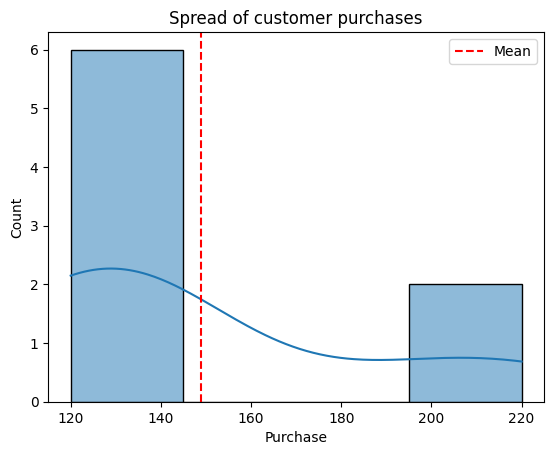

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.histplot(df['Purchase'], kde= True)
plt.axvline(mean, color = 'red', linestyle = '--', label = 'Mean')
plt.legend()

plt.title('Spread of customer purchases')
plt.show()

### Percentile , quartine , IQR and Z-score

In [ ]:
import numpy as np

data = [10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40]
print("25th percentile (Q1):", np.percentile(data, 25))
print("50th percentile (Q2) or (Median):", np.percentile(data, 50))
print("75th percentile (Q3):", np.percentile(data, 75))

25th percentile (Q1): 15.75
50th percentile (Q2) or (Median): 24.0
75th percentile (Q3): 33.0


In [ ]:
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

print(Q1)
print(Q3)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Interquartile Range (IQR):", IQR)
print("Outlayer Range: ", lower_bound,"to", upper_bound)

15.75
33.0
Interquartile Range (IQR): 17.25
Outlayer Range:  -10.125 to 58.875


In [ ]:
import numpy as np

data = [10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40]
mean = np.mean(data)
std = np.std(data)

z_scores= [(x- mean)/ std for x in data]
print("Z-scores:", np.round(z_scores, 2))

Z-scores: [-1.5  -1.29 -1.19 -0.98 -0.66 -0.35 -0.14  0.07  0.38  0.59  1.01  1.11
  1.32  1.63]


In [ ]:
import pandas as pd
import numpy as np
df = pd.DataFrame({'Income': [22, 25, 27, 29, 35, 40, 42, 100,110, 115]})

# IQR
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['Income'] < lower_bound) | (df['Income'] > upper_bound)]
print("Outliers using iqr: ", outliers_iqr)


#  Z score
mean = df['Income'].mean()
std = df['Income'].std()
z_scores = (df['Income'] - mean) / std
outliers_zscore = df[np.abs(z_scores) > 2.5]
print("Outliers using Z-score: ", outliers_zscore)

# Modified Z score
#  generally a threshold is between the range of 2 to 4
# Normal Z-score uses mean and standard deviation.
# Outliers pull the mean and std towards themselves, so they can hide and become harder to detect.
# Modified Z-score uses median and MAD (Median Absolute Deviation).
# These are robust — outliers don’t affect them much. So it detects outliers more reliably.


median = df['Income'].median()
# calculate how far each value is from the median
# now mad is the median of the distances of each element from the median
mad = np.median(np.abs(df['Income'] - median))

z_scores_modified = (df['Income'] - median) / (1.4826 * mad)

# now keep the rows where this z_score_modified value is greater than 2.5, cause they are the detected outliers
outliers_modified = df[np.abs(z_scores_modified) > 2.5]
print("Outliers using modified Z-score" , outliers_modified)

#  mad (median absolute deviation) is basically median of those deviations

Outliers using iqr:  Empty DataFrame
Columns: [Income]
Index: []
Outliers using Z-score:  Empty DataFrame
Columns: [Income]
Index: []
Outliers using modified Z-score    Income
7     100
8     110
9     115


## Scaling, Encoding and Distances

### Z-Score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({'h' : [150,160, 170, 185, 190], 'w' :[50, 58, 70, 80,90]})
# print(df)
m = df.mean()
# print(m)
s= df.std()
print(s)

# z value
z = (df -m) / s
z.round(2)

h    16.733201
w    16.149303
dtype: float64


,h,w
0,-1.25,-1.21
1,-0.66,-0.72
2,-0.06,0.02
3,0.84,0.64
4,1.14,1.26


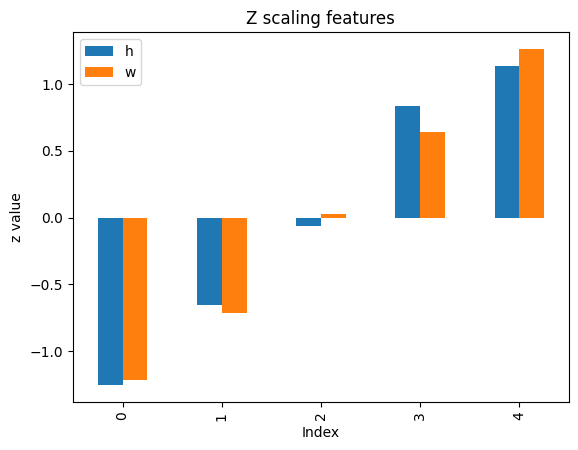

In [ ]:
z.plot(kind='bar')
plt.title("Z scaling features")
plt.xlabel("Index")
plt.ylabel('z value')
plt.show()

### Min-Max Scaling

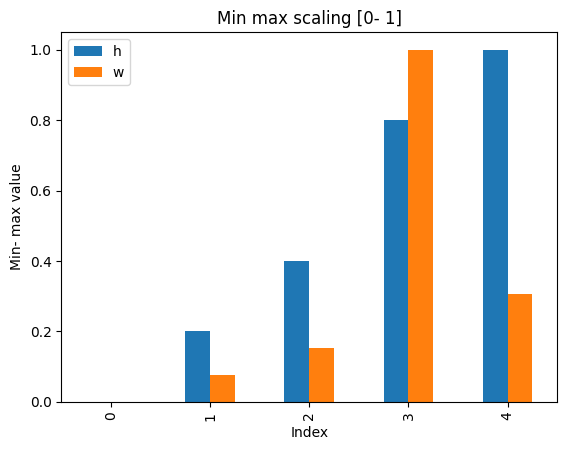

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({'h' : [150,160, 170, 190, 200], 'w' :[50, 60, 70, 180,90]})
df

#min and max value
mn = df.min()
mx = df.max();

rg =  mx- mn

# mn, mx, rg
# shift to zero
ss = df - mn
# divide by range
mm = ss / rg

mm.round(2)

# plot
mm.plot(kind = 'bar')
plt.title("Min max scaling [0- 1]")
plt.xlabel('Index')
plt.ylabel('Min- max value')
plt.show()

### Robust Scaling

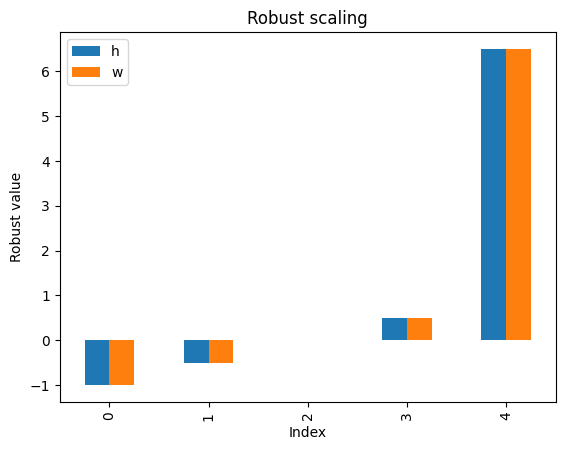

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({'h' : [150,160, 170, 180, 300], 'w' :[50, 60, 70, 80,200]})


#media, quartiles, iqr
md = df.median()
q1 = df.quantile(.25)
q3= df.quantile(.75)

iqr = q3 - q1
md, q1, q3, iqr

ct = df- md
# ct

robust_scaling = ct / iqr
robust_scaling.round(2)

#visualize
robust_scaling.plot(kind = 'bar')
plt.title("Robust scaling")
plt.xlabel('Index')
plt.ylabel('Robust value')
plt.show()

In [ ]:
#to compare every scaling method we learned
# z score
m = df.mean()
s= df.std()
z = (df- m)/ s


# min max
mn = df.min()
mx = df.max();
mm = (df - mn) /(mx - mn)

# with the output we understand that when the datapoints are semmetric then we have to use the z-score or minmax, and when there is outliers or the data isnt semmetric we have to use robust_scaling method as it finds out the outliers and points it out more clearly than the other methods
out = pd.concat([df, z.add_prefix('z_'),
                 mm.add_prefix('mm_'),
                 robust_scaling.add_prefix('rb_')],
                axis = 1)

out.round(2)

,h,w,z_h,z_w,mm_h,mm_w,rb_h,rb_w
0,150,50,-0.68,-0.68,0.00,0.00,-1.0,-1.0
1,160,60,-0.52,-0.52,0.07,0.07,-0.5,-0.5
2,170,70,-0.36,-0.36,0.13,0.13,0.0,0.0
3,180,80,-0.20,-0.20,0.20,0.20,0.5,0.5
4,300,200,1.76,1.76,1.00,1.00,6.5,6.5


### One-Hot encoding for Nominal Values

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "id" : [1, 2,  3, 4],
    "color" : ["red", "blue", "green", "red"],
    "size" : ["Small", "Medium", "Large" , "Medium"],
    "price" : [10, 12, 15, 11]
})

# step 2 -> apply one-hot encoding to the color column
# they are called dummy variable because each new column represent whether a category is present ot not, like if "is the color red? then 1 otherwise 0"
# dummies simply means the new 0/1 columns created by one-hot encoding
d_color = pd.get_dummies(df["color"], prefix= "color", dtype = int)

#step 3 -> combine the new columns back with the original data
# axis =1, cause i am joining d_color to the original df side by side, meaning i am adding new columns
df_encoded = pd.concat([df, d_color], axis = 1)


# drop the old 'color column if you no longer need itr
df_encoded = df_encoded.drop("color" , axis = 1)
print(df_encoded)

   id    size  price  color_blue  color_green  color_red
0   1   Small     10           0            0          1
1   2  Medium     12           1            0          0
2   3   Large     15           0            1          0
3   4  Medium     11           0            0          1


### Ordinal Encoding

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "id" : [1, 2,  3, 4],
    "color" : ["red", "blue", "green", "red"],
    "size" : ["Small", "Medium", "Large" , "Medium"],
    "price" : [10, 12, 15, 11]
})

# step 2 -> declare the ordinal order
order = {"Small" : 1 , "Medium" :2 , "Large" : 3}

# step 3 -> convert the whole feature
df["size_encoded"] = df["size"].map(order).astype(int)

df

,id,color,size,price,size_encoded
0,1,red,Small,10,1
1,2,blue,Medium,12,2
2,3,green,Large,15,3
3,4,red,Medium,11,2


### Vectors, dot product, and norms

In [ ]:
#Step 1: creating vectors
import numpy as np

# two tiny 3d vectors
a = np.array([2, 1, 3])
b = np.array([1, 3,3 ])

# print(a)
# print(b)

#step 2 : vector operations (addition and substraction)
add_ab = a+ b
sub_ab = a- b

print(add_ab)
print(sub_ab)

# step 3 : dot product (similarity of direction)

dot_np = np.dot(a,b)

dot_np

# step 4 : norms (lenght or  magnitude of a vector)
#  L1 is the sum of abs values
#  L2 norm, the usual lenght
# L2 norm is the Euclidean length of the vector.
l2_a = np.linalg.norm(a)
print(l2_a)
l1_a= np.linalg.norm(a, ord = 1)
print(l1_a)

# step 5 : Normalizing a vector (unit vector)
# We normalize a vector to make its length 1 while preserving its direction.
unit_a = a / np.linalg.norm(a)
len_unit_a = np.linalg.norm(unit_a)
print(unit_a)
print(len_unit_a)

[3 4 6]
[ 1 -2  0]
3.7416573867739413
6.0
[0.53452248 0.26726124 0.80178373]
1.0


### Euclidean and Manhattan Distance

In [ ]:
import numpy as np

x = np.array([
    [70, 80], #s1
    [60, 90], #s2
    [85, 60], #s3
    [78, 76], #s4
    [62, 65], #s5
], dtype=float)

# below this 75, 70 is the query point
q = np.array([75, 70], dtype = float)

# shape tells us that here 2 rows and 5 col
print("x shape:", x.shape)
# prints the query point 75 70
print("q:", q.tolist())

# Euclidean distance (L2)
eu_dis = np.linalg.norm(x- q, axis = 1)
print("Euclidean distance:", eu_dis)

# Manhattan distance (L1)
man_dis = np.linalg.norm(x -q, ord = 1, axis = 1)
print("Manhattan distance:", man_dis)

x shape: (5, 2)
q: [75.0, 70.0]
Euclidean distance: [11.18033989 25.         14.14213562  6.70820393 13.92838828]
Manhattan distance: [15. 35. 20.  9. 18.]
